<a href="https://colab.research.google.com/github/Hasmithakammula05/ML-PROJECTS/blob/main/ML_Codealpha_task_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 294ms/step - accuracy: 0.0123 - loss: 3.7142 - val_accuracy: 0.0000e+00 - val_loss: 3.7477
Epoch 2/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.0845 - loss: 3.6235 - val_accuracy: 0.0714 - val_loss: 3.7827
Epoch 3/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.1034 - loss: 3.5298 - val_accuracy: 0.0714 - val_loss: 3.8923
Epoch 4/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.1138 - loss: 3.4713 - val_accuracy: 0.0714 - val_loss: 3.9825
Epoch 5/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.0930 - loss: 3.5166 - val_accuracy: 0.0714 - val_loss: 4.0254
Epoch 6/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.1034 - loss: 3.4465 - val_accuracy: 0.0714 - val_loss: 4.0861
Epoch 7/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.1034 - loss: 3.4356 - val_accuracy: 0.0714 - val_loss: 4.1593
Epoch 8/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.1034 - loss: 3.4349 - val_accuracy: 0.0000e+00 - val_los

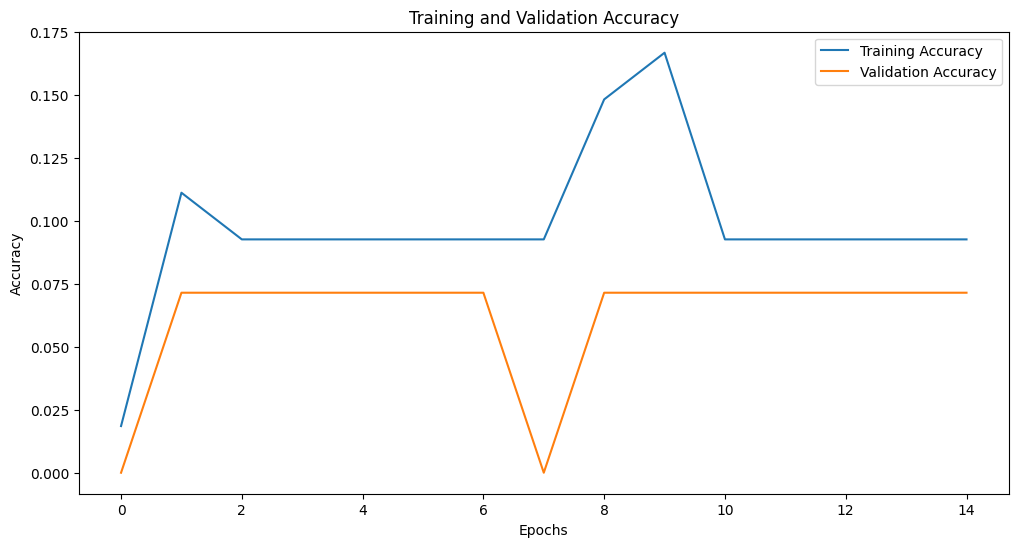

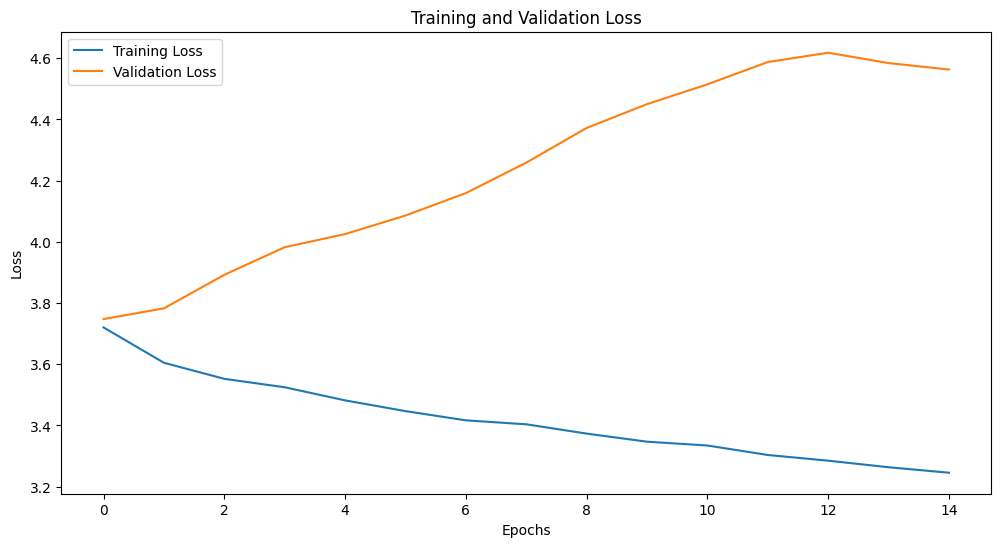

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.0714 - loss: 4.5631

Test accuracy: 0.0714


In [3]:
#Handwritten character Recognition Task 3

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Load metadata
labels_df = pd.read_csv('/content/labels.csv', header=2)
labels = labels_df['Class'].values
devnagari_chars = labels_df['Devanagari Label'].values

# Convert labels to strings
labels = labels.astype(str)

# Use LabelEncoder to convert string labels to numerical values
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)

# Image preprocessing (assuming you have image data in a 'images' directory)
# Replace this with actual image loading logic matching your dataset structure
# Example: Load 32x32 grayscale images, normalize pixel values
def load_images():
    # This is a placeholder - implement based on your image data structure
    num_samples = len(labels)
    return np.random.rand(num_samples, 32, 32, 1)  # Random dummy data

images = load_images()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    images, labels_encoded, test_size=0.2, random_state=42
)

# CNN Model Architecture
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(np.unique(labels_encoded)), activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Training
history = model.fit(X_train, y_train,
                    epochs=15,
                    validation_data=(X_test, y_test))

# Plotting training and validation accuracy
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plotting training and validation loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Evaluation
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'\nTest accuracy: {test_acc:.4f}')
